<a href="https://colab.research.google.com/github/VelasquezE/FourierOptics_assignments/blob/main/talleres/Proyecto/inline_hologram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Simulación holograma en línea**

# 0. Importar librerías necesarias

In [1]:
import numpy as np
import os
from scipy.fft import fft2, fftshift, ifftshift, ifft2, ifftshift
import scipy
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.integrate import simpson
import seaborn as sns
from scipy.fft import fftfreq

In [94]:
plt.rcParams.update({
    "text.usetex": False,
})

In [85]:
# Estilo por defecto para notebooks
sns.set_context("notebook", font_scale=1.5, rc={"lines.linewidth": 2.5})

# Personalización gráficas

sns.set_style("darkgrid")

custom_rc = {
    "xtick.bottom": True,
    "ytick.left": True,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.edgecolor": "black",
    "grid.color": "#bbbbbb",
    "grid.linestyle": "dashed",
    "axes.grid": True,
    "axes.spines.top": True,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": True
}
sns.set_context("notebook")
sns.set_style("darkgrid", rc = custom_rc)

Se crea una carpeta de registro y una de resultados,

In [3]:
register_folder = "register"
os.makedirs(register_folder, exist_ok = "True")

results_folder = "results"
os.makedirs(results_folder, exist_ok = "True")

# 1. Creación del objeto

Se creará un círculo no-absorbente (introduce un cambio de fase pero no atenúa la luz) con fase constante. Para ello, se crea una rejilla llena de unos, con una máscara circular de fase arbitraria.

In [36]:
def create_circle(r: float, phase: float, N: int) -> np.ndarray:
  """
  Creates a circle with amplitude 1 in an N x N
  square.

  Parameters:
    r: float
      Circle radius in pixels.
    phase: float
      Desired phase for the object.
    N: int
      Size of the grid.
  Returns:
    Circle: np.ndarray
      Non absorbent circle with given phase.
  """
  center = N / 2
  W, H = np.meshgrid(np.arange(0, N), np.arange(0, N))
  mask = np.sqrt((W - center) ** 2 + (H - center) ** 2) <= r

  circle = np.ones((N, N), dtype = np.complex128)
  circle[mask] = np.exp(1j * phase)

  return circle

Se da el radio deseado en micrómetros y se convierte a píxeles,

In [57]:
pixel_size = 0.1 # \mu m
r = 5.0 # \mu m

In [58]:
def milimeters_to_pixel(x:int, pixel_size: float):
  """
  Returns the equivalent in pixels for
  the given milimeters.
  Parameters:
    x (float): Value in milimeters
  Returns:
    Returns the value in pixels.
  """
  return (x / pixel_size)

r_pixels = milimeters_to_pixel(r, pixel_size)

print(f"Radio en píxeles: {r_pixels}")

Radio en píxeles: 50.0


In [59]:
N = 512 # px
phase = 0.75 # radians

object_circle = create_circle(r_pixels, phase, N)

El objeto puede visualizarse,

In [60]:
def plot_complex_visualization(field: np.ndarray, is_log_scale: bool = False):
  """
  Plots the phase and amplitude of a given field.
  Returns all the plot parameters for customization.

  Parameters:
    field: np.ndarray
      Complex array for plotting.
    is_log_scale: bool
      Whether the amplitude requires to be in log_scale
      to be visualize.
  Returns:
    fig, ax1, ax2, amplitude, phase, amplitude_cb,
    phase_cb.
  """
  fig, (ax1, ax2) = plt.subplots(1, 2)

  amplitude = np.abs(field)
  if is_log_scale:
    amplitude = np.log(amplitude)
  amplitude_im = ax1.imshow(amplitude, cmap = "viridis")
  ax1.set_title("Amplitud")
  ax1.axis("off")
  divider = make_axes_locatable(ax1)
  cax = divider.append_axes("right", size = "5%", pad = 0.05)
  amplitude_cb = fig.colorbar(amplitude_im, cax = cax)

  phase = np.angle(field)
  phase_im = ax2.imshow(phase, vmin = 0, vmax = 2 * np.pi, cmap = "viridis")
  ax2.set_title("Fase")
  ax2.axis("off")
  divider = make_axes_locatable(ax2)
  cax = divider.append_axes("right", size = "5%", pad = 0.05)
  phase_cb = fig.colorbar(phase_im, cax = cax)
  phase_cb.set_ticks([0, 2*np.pi])
  phase_cb.set_ticklabels(['0', r'2$\pi$'])

  return fig, ax1, ax2, amplitude, phase, amplitude_cb, phase_cb

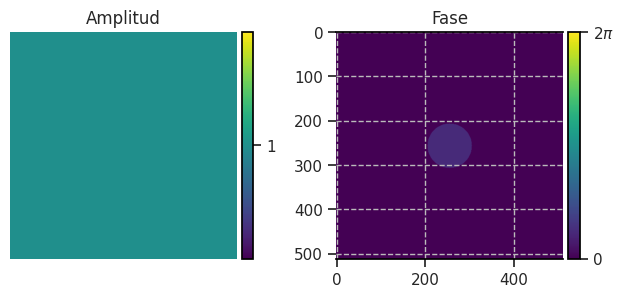

In [61]:
_, _, ax2, _, _, amplitude_cb, _ =plot_complex_visualization(object_circle)
amplitude_cb.set_ticks([1])
ax2.axis("on")
plt.tight_layout(h_pad = 0.2)

plt.savefig(f"{register_folder}/object.svg", dpi = 400, bbox_inches = "tight")

# 2. Calcular las frecuencias espaciales

Para la simulación, se usará el método de propagación del espectro angular. Este requiere conocer los valores en el espectro de frecuencias.

Se define el sistema de coordenadas del plano espacial,

In [62]:
x = np.linspace(-pixel_size * N / 2, pixel_size * N / 2, num = N, endpoint = True)

Para realizar la transformada de Fourier es necesario definir los arreglos de las frecuencias espaciales. Para ello, se calcula el espacio entre puntos, se define el tamaño del píxel en el domino de frecuencias, y finalmente se crea el arreglo de frecuencias espaciales permitidas.

In [77]:
dx = np.diff(x)[0]
sampling_freq = 1 / dx
df = sampling_freq / N
f = fftshift(fftfreq(len(x), dx))

In [90]:
def get_frequency_info(N: int, pixel_size: float):
  """
  Get the pixel size in the frequency domain
  and the frequencies array.
  Parameters:
    N: int
      Number of pixels.
    pixel_size: float.
      Size of the pixel in the space.
  """
  x = np.linspace(-pixel_size * N / 2, pixel_size * N / 2, num = N, endpoint = True)

  dx = np.diff(x)[0]
  sampling_freq = 1 / dx
  df = sampling_freq / N
  f = fftshift(fftfreq(len(x), dx))

  return df, f, sampling_freq

# 3. Generar el holograma

Se asume que se ilumina el objeto con una onda plana.

## 3.1. Calcular la transformada de Fourier del objeto

$ U(f_x, f_y) = \sum u(x,y)e^{-i2\pi(f_x x + f_y y)}\Delta x \Delta y $

In [9]:
def get_fourier_transform(matrix: np.ndarray, delta_x) -> np.ndarray:
  """
  Calculates the fourier transform and centers it.

  Parameters:
    - matrix (np.ndarray)
  """
  fourier_transform = fftshift(fft2(ifftshift(matrix))) * (delta_x**2)
  return fourier_transform

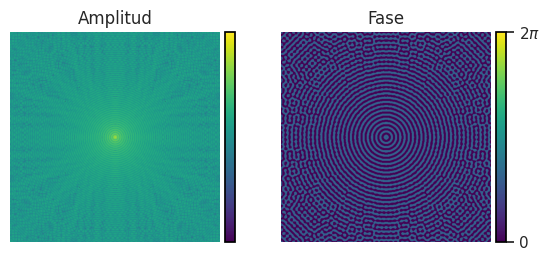

In [103]:
fft_object = get_fourier_transform(object_circle, dx)

fig, ax1, ax2, amplitude, phase, amplitude_cb, phase_cb = plot_complex_visualization(fft_object, is_log_scale = True)

amplitude_cb.set_ticks([])
plt.savefig(f"{register_folder}/fft_object.svg", dpi = 400, bbox_inches = "tight")

Hay dos formas de verificar que la transformada de Fourier es correcta.

**Teorema de Parseval**

Se verifica que la energía total en el dominio espacial sea igual a la energía contenida en la transformada.

Si $\mathcal{F}\{g(x,y)\} = G(f_{X}, f_{Y})$ ,

$\int\int^{\infty}_{\infty} |g(x,y)|^{2} dxdy = \int\int^{\infty}_{\infty} |G(f_{X},f_{Y})|^{2} df_{X}df_{y}$

In [120]:
def give_energy_report(original, fft, dx, df):
  original_int = simpson(simpson(np.abs(original)**2, dx=dx), dx=dx)
  fft_int = simpson(simpson(np.abs(fft)**2, dx=df), dx=df)
  error = np.abs(original_int - fft_int) / original_int * 100

  print(f"Energía del objeto: {original_int:0.2f}")
  print(f"Energía de la transformada de Fourier: {fft_int:0.2f}")
  print(f"Porcentaje de error: {error:0.2f} %")

In [121]:
give_energy_report(object_circle, fft_object, dx, df)

Energía del objeto: 2621.44
Energía de la transformada de Fourier: 1193.13
Porcentaje de error: 54.49 %


**Coeficiente DC**

In [12]:
# Compute the average of the original object
gt_avg = np.sum(object_circle) * dx**2 / (x[-1] - x[0])**2
print('Average of the object field: {:.4f}'.format(gt_avg))

Average of the object field: 0.9959+0.0205j


In [13]:
dc_term = fft_object[N // 2, N // 2] * df**2
print('DC term: {:.4f}'.format(dc_term))

DC term: 0.9920+0.0204j


## 3.2. Crear el propagador de espectro angular

Con la transformada de Fourier del objeto se obtuvo el arreglo de ondas planas que viajan formando el objeto. Para conocer el campo en otro plano, se debe hacer avanzar la fase de cada onda plana en una cantidad que depende de la longitud de onda de la luz y del ángulo al que viaja respecto al eje óptico.
Esto se logra multiplicando la transformado de Fourier del objeto con la función de transferencia del espacio libre.

In [14]:
def H(fx, fy, z, wavelength=0.5):
  argument = 1 - (wavelength*fx)**2 - (wavelength*fy)**2
  argument[argument < 0] = 0
  square_root = np.sqrt(argument)
  factor = 1j * 2 * np.pi * z / wavelength
  return np.exp(factor * square_root)

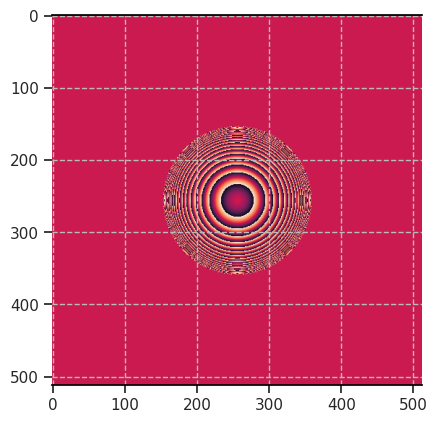

In [15]:
FX, FY = np.meshgrid(f, f)
propagator = H(FX, FY, 10)

fig, ax = plt.subplots(nrows=1, ncols=1)
img = ax.imshow(np.angle(propagator))

(<Figure size 640x480 with 4 Axes>,
 <Axes: title={'center': 'Amplitud'}>,
 <Axes: title={'center': 'Fase'}>,
 array([[1.01035208, 1.0068454 , 0.99929598, ..., 0.99375839, 0.99929598,
         1.0068454 ],
        [1.0068454 , 1.00422876, 0.99875314, ..., 0.99514314, 0.99875314,
         1.00422876],
        [0.99929598, 0.99875314, 0.99804954, ..., 0.99871269, 0.99804954,
         0.99875314],
        ...,
        [0.99375839, 0.99514314, 0.99871269, ..., 1.00277156, 0.99871269,
         0.99514314],
        [0.99929598, 0.99875314, 0.99804954, ..., 0.99871269, 0.99804954,
         0.99875314],
        [1.0068454 , 1.00422876, 0.99875314, ..., 0.99514314, 0.99875314,
         1.00422876]]),
 array([[-0.00083888, -0.00057025, -0.00015562, ..., -0.00022219,
         -0.00015562, -0.00057025],
        [-0.00057025, -0.00027536,  0.00019512, ...,  0.00017193,
          0.00019512, -0.00027536],
        [-0.00015562,  0.00019512,  0.0007781 , ...,  0.00082837,
          0.0007781 ,  0.0001

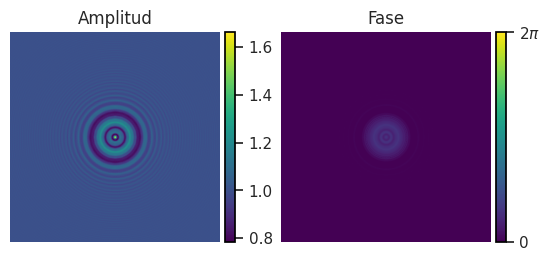

In [16]:
distance = 10 # microns
gt_prime = fftshift(ifft2(ifftshift(fft_object * H(FX, FY, distance)))) / dx**2
plot_complex_visualization(gt_prime)

In [17]:
gt_int       = simpson(simpson(np.abs(object_circle)**2, dx=dx), dx=dx)
GT_int       = simpson(simpson(np.abs(fft_object)**2, dx=df), dx=df)
gt_prime_int = simpson(simpson(np.abs(gt_prime)**2, dx=dx), dx=dx)
print('Integral, object: {:.4f}'.format(gt_int))
print('Integral, Fourier transform of object: {:.4f}'.format(GT_int))
print('Integral, hologram plane: {:.4f}'.format(gt_prime_int))

Integral, object: 2621.4400
Integral, Fourier transform of object: 1193.1264
Integral, hologram plane: 2621.4418
